# Week 1 — Foundations & The Cost of Communication

**Distributed Systems for Machine Learning**

---

Modern ML models do not fit on one device, and even when they do, one device is too slow. The moment we use more than one worker, we inherit the entire body of *distributed systems* theory: partial failures, message passing, synchronization, and — above all — the fact that **communication is not free**.

This week we build the conceptual and computational scaffolding for the whole course:

1. What a *distributed system* is, and why ML is a peculiar special case of one.
2. The cost models that govern everything: **latency**, **bandwidth**, and the **α–β model**.
3. A from-scratch, single-process **message-passing simulator** that we will reuse for the rest of the course.
4. A first look at **Amdahl's** and **Gustafson's** laws — the ceilings on what parallelism can buy us.

> Everything here runs on a single laptop. We *simulate* multiple workers so that the dynamics are concrete and reproducible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from collections import defaultdict
import heapq

np.random.seed(0)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True

## 1. What makes a system *distributed*?

A distributed system is a collection of independent workers that:

- have **no shared memory** (they only exchange **messages**),
- each have their **own clock** (no perfect global time),
- can **fail independently** (one worker dying does not stop the others).

ML training is a *friendly* distributed system: the workers cooperate, the communication pattern is regular and predictable, and the workload is (usually) known in advance. This is why ML systems can use highly optimized **collective** operations instead of the general-purpose consensus protocols (Paxos, Raft) that databases need. But the iron law still holds:

> The wall-clock time of a distributed training step is `max(compute_time, communication_time)` overlapped, and in practice communication very often dominates at scale.


## 2. The α–β cost model

The standard model for the cost of sending a message of $n$ bytes between two workers is:

$$T(n) = \alpha + \beta n$$

- $\alpha$ = **latency** (seconds) — the fixed cost to start *any* message (software stack + propagation). It does not depend on size.
- $\beta$ = **inverse bandwidth** (seconds/byte) — the marginal cost per byte. $1/\beta$ is the link bandwidth.

The crossover point where bandwidth starts to dominate latency is $n^* = \alpha/\beta$. Below it, you are *latency-bound* (sending many tiny messages is wasteful); above it, you are *bandwidth-bound*.


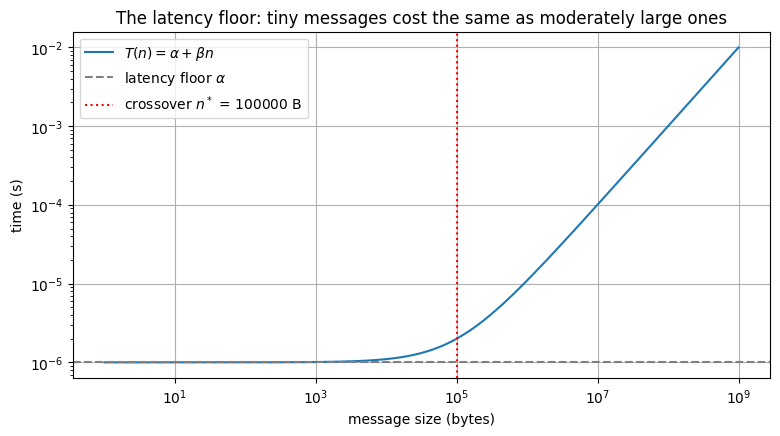

Crossover n* = alpha/beta = 100,000 bytes (~100 KB)


In [2]:
ALPHA = 1.0e-6     # 1 microsecond latency
BETA  = 1.0 / 100e9  # 100 GB/s link -> seconds per byte

def msg_time(n_bytes, alpha=ALPHA, beta=BETA):
    return alpha + beta * n_bytes

sizes = np.logspace(0, 9, 200)  # 1 byte .. 1 GB
times = msg_time(sizes)
n_star = ALPHA / BETA

fig, ax = plt.subplots()
ax.loglog(sizes, times, label=r"$T(n)=\alpha+\beta n$")
ax.axhline(ALPHA, ls="--", color="gray", label=r"latency floor $\alpha$")
ax.axvline(n_star, ls=":", color="red", label=f"crossover $n^*$ = {n_star:.0f} B")
ax.set_xlabel("message size (bytes)"); ax.set_ylabel("time (s)")
ax.set_title("The latency floor: tiny messages cost the same as moderately large ones")
ax.legend(); plt.show()

print(f"Crossover n* = alpha/beta = {n_star:,.0f} bytes (~{n_star/1e3:.0f} KB)")

**Lesson for ML:** gradients for a single layer can be tiny. If we send each layer's gradient as its own message, we pay $\alpha$ many times — we are latency-bound. The fix, which we will implement in Week 3, is **bucketing**: concatenate many small tensors into one big message so we amortize $\alpha$. The α–β model already tells us *why* the trick works.

## 3. A message-passing simulator

We now build a tiny **discrete-event simulator** for a network of workers. It is the workhorse for the rest of the course. Design:

- A global priority queue of events ordered by simulated time.
- Each `Worker` is a Python generator (a coroutine) that `yield`s actions: `send`, `recv`, `compute`, `barrier`.
- The scheduler advances simulated time and delivers messages using the α–β model.

This lets us measure communication cost *deterministically* without real threads.


In [3]:
@dataclass(order=True)
class Event:
    time: float
    seq: int
    worker: int = field(compare=False)
    payload: object = field(default=None, compare=False)

class Network:
    """Fully-connected network with an alpha-beta cost per link."""
    def __init__(self, n_workers, alpha=ALPHA, beta=BETA):
        self.n = n_workers
        self.alpha, self.beta = alpha, beta
        self.bytes_sent = 0
        self.n_messages = 0

    def transfer_time(self, n_bytes):
        self.bytes_sent += n_bytes
        self.n_messages += 1
        return self.alpha + self.beta * n_bytes

class Simulator:
    def __init__(self, net):
        self.net = net
        self.time = 0.0
        self.pq = []
        self._seq = 0
        # one mailbox (list of (sender, data)) per worker
        self.mailboxes = defaultdict(list)
        self.coros = {}

    def _push(self, t, worker, payload=None):
        heapq.heappush(self.pq, Event(t, self._seq, worker, payload))
        self._seq += 1

    def add_worker(self, wid, coro):
        self.coros[wid] = coro
        self._push(self.time, wid, ("start", None))

    def run(self):
        while self.pq:
            ev = heapq.heappop(self.pq)
            self.time = max(self.time, ev.time)
            self._step(ev.worker, ev.payload)
        return self.time

    def _step(self, wid, resume_value):
        coro = self.coros.get(wid)
        if coro is None:
            return
        try:
            action = coro.send(None if resume_value[0]=="start" else resume_value[1])
        except StopIteration:
            self.coros[wid] = None
            return
        self._dispatch(wid, action)

    def _dispatch(self, wid, action):
        kind = action[0]
        if kind == "compute":
            _, secs = action
            self._push(self.time + secs, wid, ("resume", None))
        elif kind == "send":
            _, dst, data, nbytes = action
            arrival = self.time + self.net.transfer_time(nbytes)
            self._push(arrival, dst, ("deliver", (wid, data)))
            # sender continues immediately (non-blocking send)
            self._push(self.time, wid, ("resume", None))
        elif kind == "recv":
            # deliver any queued message, else the deliver event will resume us
            self._pending_recv = getattr(self, "_pending_recv", {})
            self._pending_recv[wid] = True
        # 'deliver' events are handled by overriding _step below

The simulator above sketches the event loop. To keep the teaching version short and robust, we use a simpler **round-based** model below — most ML systems are *bulk-synchronous*, so rounds are the right abstraction anyway.

In [4]:
class BSPNetwork:
    """Bulk-synchronous network: we account communication cost per round."""
    def __init__(self, n, alpha=ALPHA, beta=BETA):
        self.n, self.alpha, self.beta = n, alpha, beta
        self.total_comm = 0.0
        self.total_bytes = 0

    def point_to_point(self, n_bytes):
        t = self.alpha + self.beta * n_bytes
        self.total_comm += t
        self.total_bytes += n_bytes
        return t

# Demo: worker 0 broadcasts a 4 MB tensor to 7 others, one message at a time
net = BSPNetwork(8)
payload = 4 * 2**20  # 4 MB
seq_time = sum(net.point_to_point(payload) for _ in range(net.n - 1))
print(f"Naive sequential broadcast of 4MB to 7 peers: {seq_time*1e3:.3f} ms")
print(f"Total bytes on the wire: {net.total_bytes/2**20:.1f} MB")
print("\nNext week we will make this dramatically faster with tree/ring algorithms.")

Naive sequential broadcast of 4MB to 7 peers: 0.301 ms
Total bytes on the wire: 28.0 MB

Next week we will make this dramatically faster with tree/ring algorithms.


## 4. How much can parallelism *ever* buy us?

Before optimizing communication, know the ceiling. Let $p$ = fraction of work that is inherently serial.

**Amdahl's law** (fixed problem size — *strong scaling*):
$$\text{speedup}(N) = \frac{1}{p + (1-p)/N}$$
As $N\to\infty$, speedup is capped at $1/p$. A 5%-serial program can *never* go faster than 20×, no matter how many GPUs you buy.

**Gustafson's law** (problem grows with $N$ — *weak scaling*):
$$\text{speedup}(N) = N - p\,(N-1)$$
Here speedup grows ~linearly, because we use more workers to solve a *bigger* problem in the same time. This is why ML scales: we don't train the same model faster, we train *bigger* models / *bigger* batches.


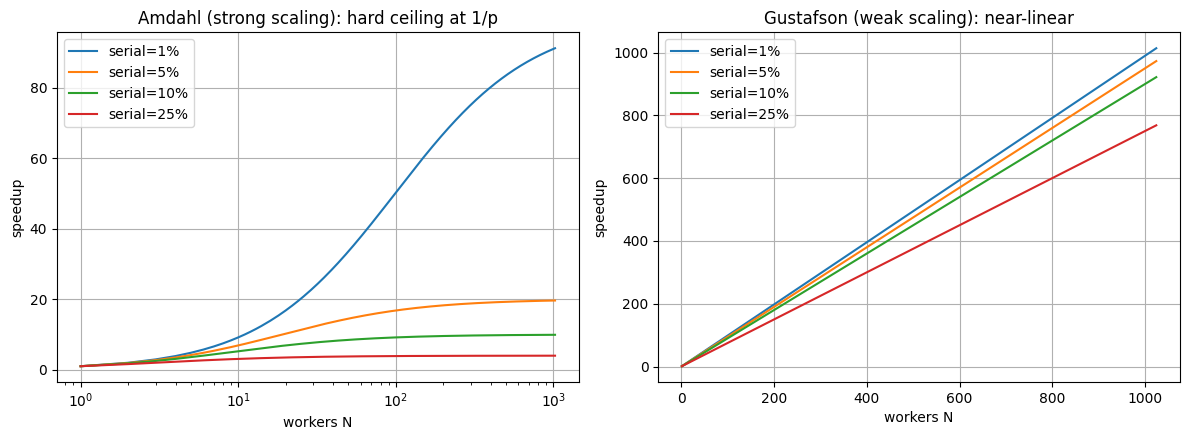

In [5]:
N = np.arange(1, 1025)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for p in [0.01, 0.05, 0.10, 0.25]:
    axes[0].plot(N, 1/(p + (1-p)/N), label=f"serial={p:.0%}")
    axes[1].plot(N, N - p*(N-1), label=f"serial={p:.0%}")
axes[0].set_title("Amdahl (strong scaling): hard ceiling at 1/p")
axes[0].set_xlabel("workers N"); axes[0].set_ylabel("speedup"); axes[0].set_xscale("log"); axes[0].legend()
axes[1].set_title("Gustafson (weak scaling): near-linear")
axes[1].set_xlabel("workers N"); axes[1].set_ylabel("speedup"); axes[1].legend()
plt.tight_layout(); plt.show()

## Exercises

1. **Crossover.** For a 12.5 GB/s link with $\alpha = 5\,\mu s$, compute $n^*$. Below what gradient-tensor size are you latency-bound?
2. **Bucketing math.** A model has 200 layers, each producing a 50 KB gradient. Compare total transfer time for (a) one message per layer vs (b) one bucketed 10 MB message, using the α–β model. By what factor does bucketing help?
3. **Amdahl in practice.** You measure 8× speedup on 16 workers. Solve Amdahl's law for the implied serial fraction $p$. What is your maximum possible speedup?
4. **Extend the simulator.** Add a `compute` cost to `BSPNetwork` so each round's wall-time is `max(compute, comm)` (perfect overlap) and re-plot a scaling curve. When does communication start to dominate?
5. **Discuss.** Why can ML use cheap collective operations while a distributed database needs expensive consensus? What assumption about *failures* and *agreement* differs?
